# Turbofan Engine RUL Prediction — Feature Engineering & Baseline Models
 
This notebook prepares the NASA C-MAPSS turbofan dataset for modeling and establishes baseline performance for Remaining Useful Life (RUL) prediction. It covers RUL label generation, sensor selection, feature engineering (rolling statistics and differencing), normalization, and evaluation of classical machine learning baselines.
 
**Input:** Raw C-MAPSS training data (`train_FD001`–`train_FD004`) — engine unit, cycle, operational settings, and 21 sensor readings.
 
**Output:** Processed train/validation splits per dataset, a saved XGBoost baseline model (`xgb_fd001.pkl`), and baseline RMSE/CMAPSS scores that later deep learning models (Notebook 3 onward) are compared against.
 
**Objective:** Turn raw sensor logs into a clean, leakage-free modeling dataset and confirm that classical ML models produce a sane, defensible baseline before moving to sequence models.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random

In [2]:
SEED = 42
random.seed(SEED) 
np.random.seed(SEED)

## RUL Label Generation
 
RUL (Remaining Useful Life) represents the number of operating cycles remaining before an engine reaches end-of-life. It is computed per unit as `max_cycle − current_cycle`.
 
**Methodological Decision:** RUL is capped at 125 cycles. Early in an engine's life, degradation is not yet observable in the sensors, so an uncapped linear RUL target would ask the model to predict a value it has no signal for. Capping reflects the standard C-MAPSS approach and keeps the label consistent with published baselines.

In [ ]:
BASE_PATH = 'C:/Users/HP/Desktop/turbofan-rul-forecasting'

cols = ['unit', 'cycle', 'op1', 'op2', 'op3'] + [f'sensor_{i}' for i in range(1, 22)]
sensor_cols = [c for c in cols if 'sensor' in c]

datasets = {}
for fd in ['FD001', 'FD002', 'FD003', 'FD004']:
    df = pd.read_csv(f'{BASE_PATH}/data/raw/train_{fd}.txt', sep=r'\s+', header=None, names=cols)
    df['dataset'] = fd
    datasets[fd] = df

def compute_rul(df, cap=125):
    max_cycle = df.groupby('unit')['cycle'].max().reset_index()
    max_cycle.columns = ['unit', 'max_cycle']
    df = df.merge(max_cycle, on='unit')
    df['RUL'] = (df['max_cycle'] - df['cycle']).clip(upper=cap)
    df.drop('max_cycle', axis=1, inplace=True)
    return df

for fd in datasets:
    datasets[fd] = compute_rul(datasets[fd])

## Sensor Analysis — Removing Uninformative Sensors
 
Not all 21 sensors vary meaningfully within a dataset. Sensors with near-zero standard deviation carry no degradation signal and only add noise, so they are excluded before feature engineering.
 
**Methodological Decision:** Sensors with standard deviation below 0.01 on FD001 are flagged as "flat" and removed from the informative sensor set used for correlation analysis and downstream feature engineering.

In [ ]:
sensor_std = datasets['FD001'][sensor_cols].std()
flat_sensors = sensor_std[sensor_std < 0.01].index.tolist()
informative_sensors = [c for c in sensor_cols if c not in flat_sensors] 

In [ ]:
print(datasets['FD001']['RUL'].describe())
print("RUL min:", datasets['FD001']['RUL'].min())
print("RUL max:", datasets['FD001']['RUL'].max())


count    20631.000000
mean        86.829286
std         41.673699
min          0.000000
25%         51.000000
50%        103.000000
75%        125.000000
max        125.000000
Name: RUL, dtype: float64
RUL min: 0
RUL max: 125


**Key Insight:** RUL for FD001 ranges from 0 to 125 across 20,631 rows, with a mean of ~86.8 cycles, confirming the cap is applied correctly and the distribution is right-skewed toward healthy engines (median 103, since most cycles are far from failure).

## Sensor–RUL Correlation (Raw Signal)
 
Before engineering any features, we check how strongly each informative sensor correlates with RUL in its raw form. This establishes a baseline to measure whether feature engineering actually improves signal quality.

In [5]:
raw_corr = datasets['FD001'][informative_sensors + ['RUL']].corr()['RUL'].drop('RUL').abs()
print(f"Average |correlation| with RUL — raw sensors: {raw_corr.mean():.3f}")
raw_corr.sort_values(ascending=False)

Average |correlation| with RUL — raw sensors: 0.660


sensor_11    0.775230
sensor_4     0.757157
sensor_12    0.748870
sensor_7     0.733021
sensor_15    0.720858
sensor_21    0.707334
sensor_20    0.704626
sensor_17    0.680829
sensor_2     0.678458
sensor_3     0.655030
sensor_8     0.624568
sensor_13    0.624034
sensor_9     0.462151
sensor_14    0.369753
Name: RUL, dtype: float64

**Key Insight:** Average absolute correlation with RUL across informative raw sensors is 0.660, led by sensor_11 (0.775), sensor_4 (0.757), and sensor_12 (0.749). This confirms the informative-sensor filter retained sensors with real predictive signal, and sets the baseline that rolling/diff features are compared against later.

## Feature Engineering — Rolling Statistics
 
Rolling mean and rolling standard deviation (window = 5 cycles, computed per engine unit) smooth out sensor noise and capture short-term trend and volatility in degradation behavior, which a single raw reading cannot represent.

In [6]:
def add_rolling_features(df, sensor_cols, window=5):
    df = df.sort_values(['unit', 'cycle']).copy()
    for col in sensor_cols:
        df[f'{col}_rollmean'] = df.groupby('unit')[col].transform(
            lambda x: x.rolling(window, min_periods=1).mean())
        df[f'{col}_rollstd'] = df.groupby('unit')[col].transform(
            lambda x: x.rolling(window, min_periods=1).std().fillna(0))
    return df

for fd in datasets:
    datasets[fd] = add_rolling_features(datasets[fd], informative_sensors)

## Feature Engineering — Cycle-to-Cycle Differencing
 
Difference features (per-unit, per-sensor) capture the rate of change between consecutive cycles rather than the absolute sensor level, which can help isolate degradation trends independent of a sensor's baseline value.

In [7]:
def add_diff_features(df, sensor_cols):
    df = df.sort_values(['unit', 'cycle']).copy()
    for col in sensor_cols:
        df[f'{col}_diff'] = df.groupby('unit')[col].diff().fillna(0)
    return df

for fd in datasets:
    datasets[fd] = add_diff_features(datasets[fd], informative_sensors)

In [8]:
print(datasets['FD001']['RUL'].describe())
print("RUL max after feature engineering:", datasets['FD001']['RUL'].max())
# should still be close to 125 — rolling/diff functions should never have touched RUL

count    20631.000000
mean        86.829286
std         41.673699
min          0.000000
25%         51.000000
50%        103.000000
75%        125.000000
max        125.000000
Name: RUL, dtype: float64
RUL max after feature engineering: 125


**Key Insight:** RUL max after feature engineering is still 125, confirming the rolling and differencing transformations did not leak into or alter the target column.

## Feature Engineering Ablation — Does It Actually Help?
 
We compare raw, rolling-mean, and rate-of-change (diff) versions of the same sensors against RUL to quantify whether the engineered features carry more signal than the raw readings, rather than assuming it.

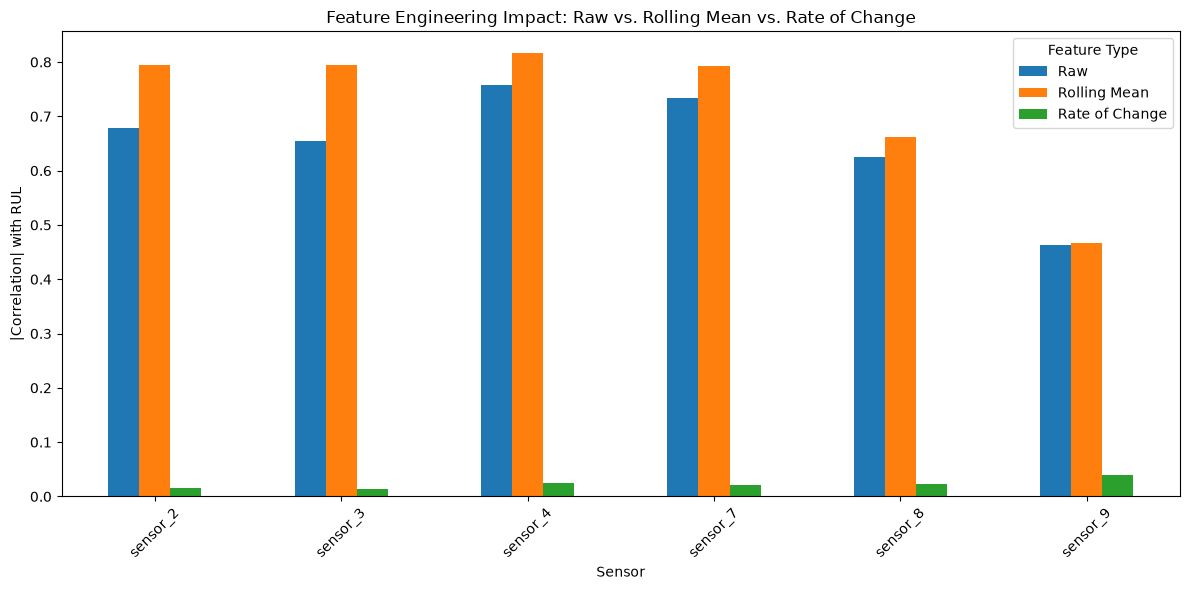


Average raw correlation: 0.652
Average rolling mean correlation: 0.721
Improvement: 10.7%


In [9]:
comparison_data = []
key_sensors_check = informative_sensors[:6]  

for sensor in key_sensors_check:
    raw_c = abs(datasets['FD001'][sensor].corr(datasets['FD001']['RUL']))
    roll_c = abs(datasets['FD001'][f'{sensor}_rollmean'].corr(datasets['FD001']['RUL']))
    diff_c = abs(datasets['FD001'][f'{sensor}_diff'].corr(datasets['FD001']['RUL']))
    comparison_data.append({'Sensor': sensor, 'Raw': raw_c, 'Rolling Mean': roll_c, 'Rate of Change': diff_c})
    
abliation_df = pd.DataFrame(comparison_data).set_index('Sensor')

abliation_df.plot(kind='bar', figsize=(12, 6))
plt.ylabel('|Correlation| with RUL')
plt.title('Feature Engineering Impact: Raw vs. Rolling Mean vs. Rate of Change')
plt.legend(title='Feature Type')  
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(f'\nAverage raw correlation: {abliation_df["Raw"].mean():.3f}')
print(f'Average rolling mean correlation: {abliation_df["Rolling Mean"].mean():.3f}')
print(f'Improvement: {(abliation_df["Rolling Mean"].mean() / abliation_df["Raw"].mean() - 1) * 100:.1f}%')  

**Key Insight:** Rolling-mean features raised average correlation with RUL from 0.652 (raw) to 0.721 — a 10.7% improvement — while rate-of-change (diff) features showed near-zero correlation with RUL. **Decision:** rolling-mean/std features are kept as primary engineered features; diff features are retained in the dataset but are not expected to carry strong standalone signal.

## Operating Condition Clustering (FD002 / FD004)
 
FD002 and FD004 include multiple operating regimes (combinations of the three operational settings), which shift sensor baselines independent of degradation. KMeans (6 clusters) is used to assign each row to an operating condition so that normalization can be done per-regime rather than globally.

**Implementation Note:** `cycle_original` is preserved before scaling is applied. Without this, the scaled `cycle` column loses its real-cycle interpretation, which breaks any downstream chart or table that needs to display actual cycle numbers (this was traced back as the root cause of a dashboard x-axis bug in the deployment stage).

Sensor features are standardized (zero mean, unit variance) so that features on different scales contribute comparably to distance- and gradient-based models. For FD002/FD004, normalization is applied separately within each operating-condition cluster, since a single global scaler would blend distinct operating regimes and distort the transformation.

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

for fd in ['FD002', 'FD004']:
    op_settings = datasets[fd][['op1', 'op2', 'op3']]
    kmeans = KMeans(n_clusters=6, random_state=42, n_init=10)
    datasets[fd]['op_condition'] = kmeans.fit_predict(op_settings)

feature_cols = [c for c in datasets['FD001'].columns
                 if c not in ['unit', 'RUL', 'dataset', 'op_condition']]

for fd in datasets:
    datasets[fd]['cycle_original'] = datasets[fd]['cycle']  # Preserve original cycle values for later use
    
def normalize_dataset(df, feature_cols, has_conditions=False):
    df = df.copy()
    if has_conditions:
        for cond in df['op_condition'].unique():
            mask = df['op_condition'] == cond
            scaler = StandardScaler()
            df.loc[mask, feature_cols] = scaler.fit_transform(df.loc[mask, feature_cols])  
    else:
        scaler = StandardScaler()
        df[feature_cols] = scaler.fit_transform(df[feature_cols])   
    return df

datasets['FD001'] = normalize_dataset(datasets['FD001'], feature_cols, has_conditions=False)
datasets['FD003'] = normalize_dataset(datasets['FD003'], feature_cols, has_conditions=False)
datasets['FD002'] = normalize_dataset(datasets['FD002'], feature_cols, has_conditions=True)
datasets['FD004'] = normalize_dataset(datasets['FD004'], feature_cols, has_conditions=True)

C:\Users\HP\AppData\Local\Temp\ipykernel_14576\1514440918.py:21: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[-1.57022902 -1.35313684 -1.32419121 ...  2.56899534  2.82950597
  2.98870691]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[mask, feature_cols] = scaler.fit_transform(df.loc[mask, feature_cols])   # ← scoped to feature_cols ONLY
C:\Users\HP\AppData\Local\Temp\ipykernel_14576\1514440918.py:21: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[-0.1674041  -1.59188977 -0.1674041  ...  0.54483874  1.96932442
  2.68156725]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[mask, feature_cols] = scaler.fit_transform(df.loc[mask, feature_cols])   # ← scoped to feature_cols ONLY
C:\Users\HP\AppData\Local\Temp\ipykernel_14576\151

In [ ]:
for fd in datasets:
    rul_max = datasets[fd]['RUL'].max()
    rul_min = datasets[fd]['RUL'].min()
    print(f"{fd} — RUL range: [{rul_min:.1f}, {rul_max:.1f}]")
    print(f"{fd} — RUL min: {rul_min:.1f}, max: {rul_max:.1f}")
    # max should be close to 125 for every dataset. If any show ~1, that dataset's RUL got scaled.

# confirm feature values genuinely got normalized (mean ~0, std ~1) — the OTHER half of "did this step work correctly"
sample_check = datasets['FD001'][feature_cols[0]]
print(f"\nSample feature '{feature_cols[0]}' — mean: {sample_check.mean():.3f}, std: {sample_check.std():.3f}")
print(f"Sample feature mean: {sample_check.mean():.3f}, std: {sample_check.std():.3f}")
# mean should be close to 0, std close to 1 — confirms the FEATURES did get scaled correctly

FD001 — RUL range: [0.0, 125.0]
FD001 — RUL min: 0.0, max: 125.0
FD002 — RUL range: [0.0, 125.0]
FD002 — RUL min: 0.0, max: 125.0
FD003 — RUL range: [0.0, 125.0]
FD003 — RUL min: 0.0, max: 125.0
FD004 — RUL range: [0.0, 125.0]
FD004 — RUL min: 0.0, max: 125.0

Sample feature 'cycle' — mean: -0.000, std: 1.000
Sample feature mean: -0.000, std: 1.000


In [12]:
for fd in ['FD002', 'FD004']:
    op_dummies = pd.get_dummies(datasets[fd]['op_condition'], prefix='op_cond')
    datasets[fd] = pd.concat([datasets[fd], op_dummies], axis=1)

datasets['FD004'][[c for c in datasets['FD004'].columns if 'op_cond_' in c]].head()

,op_cond_0,op_cond_1,op_cond_2,op_cond_3,op_cond_4,op_cond_5
0,True,False,False,False,False,False
1,False,False,False,True,False,False
2,True,False,False,False,False,False
3,True,False,False,False,False,False
4,False,False,True,False,False,False


**Key Insight:** RUL range remains [0.0, 125.0] for all four datasets after normalization, and the sample feature check confirms scaling worked correctly (mean ≈ 0, std ≈ 1). This verifies normalization was applied only to features, not to the RUL target.

## Train/Validation Split — By Engine Unit
 
**Methodological Decision:** The split is performed at the engine-unit level (not the row level). Because each unit contributes many correlated rows across its operating cycles, a row-level split would let cycles from the same engine appear in both train and validation, leaking information and inflating validation performance.

In [13]:
from sklearn.model_selection import train_test_split

splits = {}
for fd, df in datasets.items():
    units = df['unit'].unique()
    train_units, val_units = train_test_split(units, test_size=0.2, random_state=42)
    splits[fd] = {
        'train': df[df['unit'].isin(train_units)],
        'val': df[df['unit'].isin(val_units)]
    }

In [14]:
for fd in splits:
    train_df = splits[fd]['train']
    val_df = splits[fd]['val']

    # 1. No overlapping engine units between train and val
    overlap = set(train_df['unit']) & set(val_df['unit'])
    print(f"{fd} — overlapping units between train/val: {overlap}")  # should print an empty set

    # 2. No duplicate rows between train and val
    dup_check = train_df.merge(val_df, how='inner')
    print(f"{fd} — duplicate rows between train/val: {len(dup_check)}")  # should be 0

    # 3. RUL still in real units in both splits
    print(f"{fd} — train RUL max: {train_df['RUL'].max():.1f}, val RUL max: {val_df['RUL'].max():.1f}")
    # both should be close to 125

    # 4. RUL is genuinely not present in the feature columns
    fd_feature_cols = [c for c in train_df.columns if c not in ['unit', 'RUL', 'dataset', 'op_condition', 'cycle_original']]
    print(f"{fd} — 'RUL' in feature list: {'RUL' in fd_feature_cols}")  # should print False

    print(f"{fd}: all integrity checks passed — train {train_df.shape}, val {val_df.shape}")

FD001 — overlapping units between train/val: set()
FD001 — duplicate rows between train/val: 0
FD001 — train RUL max: 125.0, val RUL max: 125.0
FD001 — 'RUL' in feature list: False
FD001: all integrity checks passed — train (16561, 71), val (4070, 71)
FD002 — overlapping units between train/val: set()
FD002 — duplicate rows between train/val: 0
FD002 — train RUL max: 125.0, val RUL max: 125.0
FD002 — 'RUL' in feature list: False
FD002: all integrity checks passed — train (43464, 78), val (10295, 78)
FD003 — overlapping units between train/val: set()
FD003 — duplicate rows between train/val: 0
FD003 — train RUL max: 125.0, val RUL max: 125.0
FD003 — 'RUL' in feature list: False
FD003: all integrity checks passed — train (20012, 71), val (4708, 71)
FD004 — overlapping units between train/val: set()
FD004 — duplicate rows between train/val: 0
FD004 — train RUL max: 125.0, val RUL max: 125.0
FD004 — 'RUL' in feature list: False
FD004: all integrity checks passed — train (49294, 78), val (1

In [15]:
import os
os.makedirs(f'{BASE_PATH}/data/processed', exist_ok=True)
for fd in splits:
    splits[fd]['train'].to_csv(f'{BASE_PATH}/data/processed/train_{fd}.csv', index=False)
    splits[fd]['val'].to_csv(f'{BASE_PATH}/data/processed/val_{fd}.csv', index=False)

In [ ]:
train_fd001 = pd.read_csv(f'{BASE_PATH}/data/processed/train_FD001.csv')
val_fd001 = pd.read_csv(f'{BASE_PATH}/data/processed/val_FD001.csv')

print(train_fd001['RUL'].describe())
print("Loaded train RUL max:", train_fd001['RUL'].max())
print("Loaded val RUL max:", val_fd001['RUL'].max())

feature_cols = [c for c in train_fd001.columns
                 if c not in ['unit', 'RUL', 'dataset', 'op_condition', 'cycle_original']]
print("'RUL' in feature_cols:", 'RUL' in feature_cols)  # should print False

X_train, y_train = train_fd001[feature_cols], train_fd001['RUL']
X_val, y_val = val_fd001[feature_cols], val_fd001['RUL']

print(f"X_train: {X_train.shape}, X_val: {X_val.shape}")
print(f"Same object? {X_train is X_val}")  # sanity check — should always be False

count    16561.000000
mean        86.958819
std         41.662359
min          0.000000
25%         51.000000
50%        103.000000
75%        125.000000
max        125.000000
Name: RUL, dtype: float64
Loaded train RUL max: 125
Loaded val RUL max: 125
'RUL' in feature_cols: False
X_train: (16561, 67), X_val: (4070, 67)
Same object? False


**Key Insight:** All integrity checks pass across FD001–FD004: zero overlapping units and zero duplicate rows between train/val, RUL max close to 125 in both splits, and `RUL` confirmed absent from the feature columns. This confirms the split is leakage-free before any model is trained.

## Evaluation Metrics
 
- **RMSE:** Penalizes larger prediction errors more heavily, useful for gauging overall prediction accuracy.
- **CMAPSS Score:** An asymmetric penalty function specific to this problem — late predictions (predicting more life than remains) are penalized far more heavily than early predictions, reflecting the real-world cost of an unexpected failure versus unnecessary early maintenance.

In [17]:
def cmapss_score(y_true, y_pred):
    d = y_pred - y_true
    score = np.where(d < 0, np.exp(-d/13) - 1, np.exp(d/10) - 1)
    return np.sum(score)

## Baseline Model Development
 
Random Forest and XGBoost are evaluated as baseline models before moving to deep learning. Hyperparameter search uses GroupKFold (grouped by engine unit) rather than standard k-fold, to keep the same unit-level leakage protection used in the train/val split.

In [18]:
from sklearn.model_selection import GroupKFold, RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb

group_kfold = GroupKFold(n_splits=3)
groups = train_fd001['unit']

rf_params = {'n_estimators': [100, 200, 300], 'max_depth': [8, 12, 16, None], 'min_samples_leaf': [1, 3, 5]}
rf_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    rf_params, n_iter=10, cv=group_kfold, scoring='neg_root_mean_squared_error', random_state=42
)
rf_search.fit(X_train, y_train, groups=groups)
best_rf = rf_search.best_estimator_

xgb_params = {'n_estimators': [100, 200, 300], 'max_depth': [4, 6, 8], 'learning_rate': [0.01, 0.05, 0.1]}
xgb_search = RandomizedSearchCV(
    xgb.XGBRegressor(random_state=42, n_jobs=-1),
    xgb_params, n_iter=10, cv=group_kfold, scoring='neg_root_mean_squared_error', random_state=42
)
xgb_search.fit(X_train, y_train, groups=groups)
best_xgb = xgb_search.best_estimator_

## Model Comparison — Linear Regression vs. Random Forest vs. XGBoost
 
Linear Regression is included as a simple baseline to confirm that the engineered features carry meaningful non-trivial signal — if a linear model performs close to the tree-based models, it would suggest the relationship is largely linear.

In [19]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

lr = LinearRegression().fit(X_train, y_train)
models = {'Linear Regression': lr, 'Random Forest': best_rf, 'XGBoost': best_xgb}
results = []
for name, model in models.items():
    preds = model.predict(X_val)
    rmse = np.sqrt(mean_squared_error(y_val, preds))
    score = cmapss_score(y_val.values, preds)
    results.append({'Model': name, 'RMSE': round(rmse, 2), 'CMAPSS Score': round(score, 1)})

results_df = pd.DataFrame(results)

# Sanity check — published FD001 baselines typically land in the RMSE 12-25 range.
# A number wildly outside that (either far lower OR far higher) deserves a second look before trusting it.
for _, row in results_df.iterrows():
    if row['RMSE'] < 5:
        print(f"{row['Model']}: RMSE={row['RMSE']} looks suspiciously low for FD001 — verify before trusting")

results_df

,Model,RMSE,CMAPSS Score
0,Linear Regression,17.73,21001.6
1,Random Forest,15.16,19247.5
2,XGBoost,14.75,16315.6


**Key Insight:** XGBoost achieved the best validation RMSE (14.75), followed by Random Forest (15.16) and Linear Regression (17.73). All three RMSE values fall within the range typically reported for published FD001 baselines (12–25), which is a useful sanity check that nothing is leaking into the target. **Decision:** XGBoost is selected as the baseline model carried forward for deployment and comparison against the deep learning models in later notebooks.

## Multicollinearity Check (VIF)
 
Variance Inflation Factor is checked across a subset of features to understand redundancy between raw and engineered sensor features. This is diagnostic only — tree-based models like XGBoost and Random Forest are largely robust to multicollinearity, so this does not drive feature removal, but it is useful context for interpreting feature importance.

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

check_features = feature_cols[:15]
vif_data = pd.DataFrame()
vif_data['feature'] = check_features
vif_data['VIF'] = [variance_inflation_factor(X_train[check_features].values, i) for i in range(len(check_features))]
vif_data.sort_values('VIF', ascending=False)

c:\Users\HP\Desktop\turbofan-rul-forecasting\rul_env\Lib\site-packages\statsmodels\regression\linear_model.py:1782: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
c:\Users\HP\Desktop\turbofan-rul-forecasting\rul_env\Lib\site-packages\statsmodels\regression\linear_model.py:1782: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
c:\Users\HP\Desktop\turbofan-rul-forecasting\rul_env\Lib\site-packages\statsmodels\regression\linear_model.py:1782: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.centered_tss


,feature,VIF
14,sensor_11,5.216512
7,sensor_4,4.163614
11,sensor_8,3.994537
10,sensor_7,3.941998
5,sensor_2,2.519463
6,sensor_3,2.224898
0,cycle,2.075918
12,sensor_9,1.650488
9,sensor_6,1.028603
1,op1,1.001561


## Saving the Baseline Model
 
The selected XGBoost model is serialized with `joblib` for reuse in later notebooks and in the deployment stage (FastAPI backend and Streamlit dashboard), so the model does not need to be retrained outside this notebook.

In [21]:
import joblib
joblib.dump(best_xgb, f'{BASE_PATH}/models/xgb_fd001.pkl')

['C:\\Users\\HP\\Desktop\\turbofan-rul-forecasting/models/xgb_fd001.pkl']

## Residual Analysis
 
Residual plots reveal systematic bias that a single RMSE number can hide — for example, whether the model consistently over- or under-predicts RUL at particular ranges, rather than only showing average error magnitude.

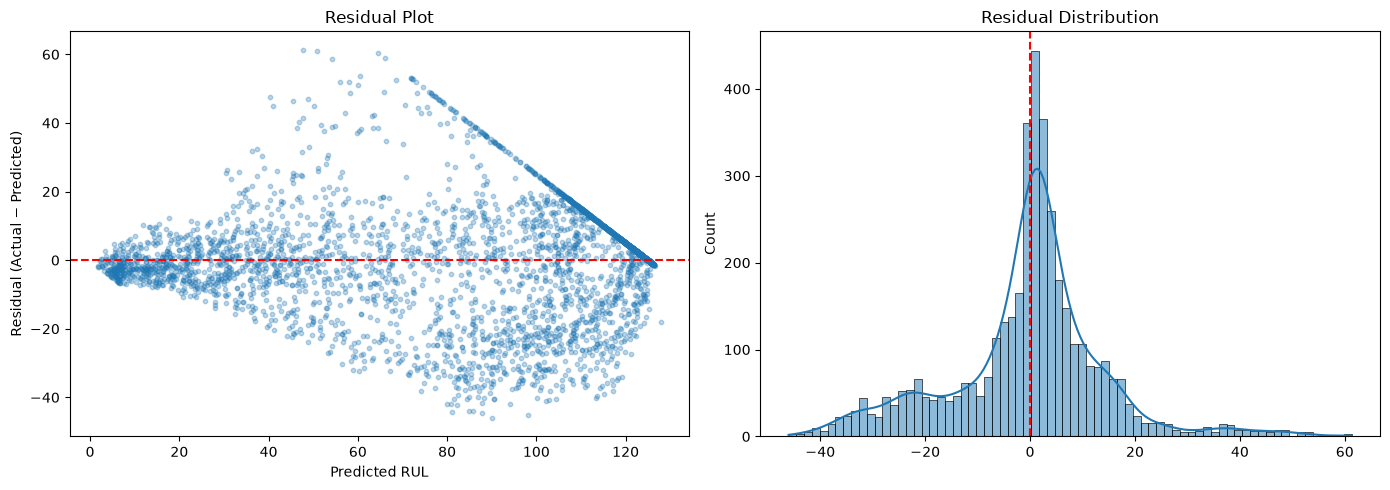

In [22]:
preds = best_xgb.predict(X_val)
residuals = y_val.values - preds

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(preds, residuals, alpha=0.3, s=10)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('Predicted RUL'); axes[0].set_ylabel('Residual (Actual − Predicted)')
axes[0].set_title('Residual Plot')

sns.histplot(residuals, kde=True, ax=axes[1])
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_title('Residual Distribution')
plt.tight_layout()
plt.show()

**Key Insight:** The residual plot shows a downward-sloping band at higher predicted RUL values, indicating the model tends to underpredict remaining life for healthier engines while residuals cluster tightly near zero at lower predicted RUL — the region that matters most for maintenance decisions.

## Feature Importance
 
Feature importance shows which engineered features the model relies on most, and lets us sanity-check that the model is learning from degradation-relevant sensors rather than incidental columns like `cycle` alone.

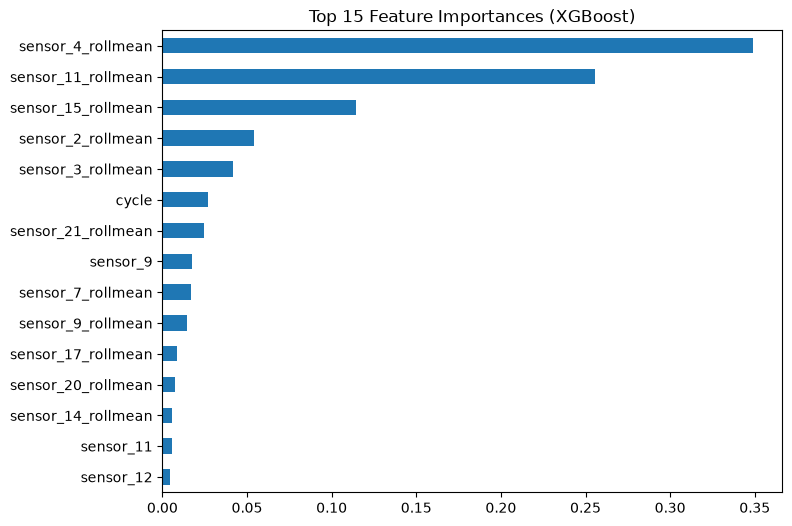

In [23]:
importances= pd.Series(best_xgb.feature_importances_, index=feature_cols).sort_values(ascending=False)
importances.head(15).plot(kind='barh', figsize=(8, 6), title='Top 15 Feature Importances (XGBoost)')
plt.gca().invert_yaxis()
plt.show()

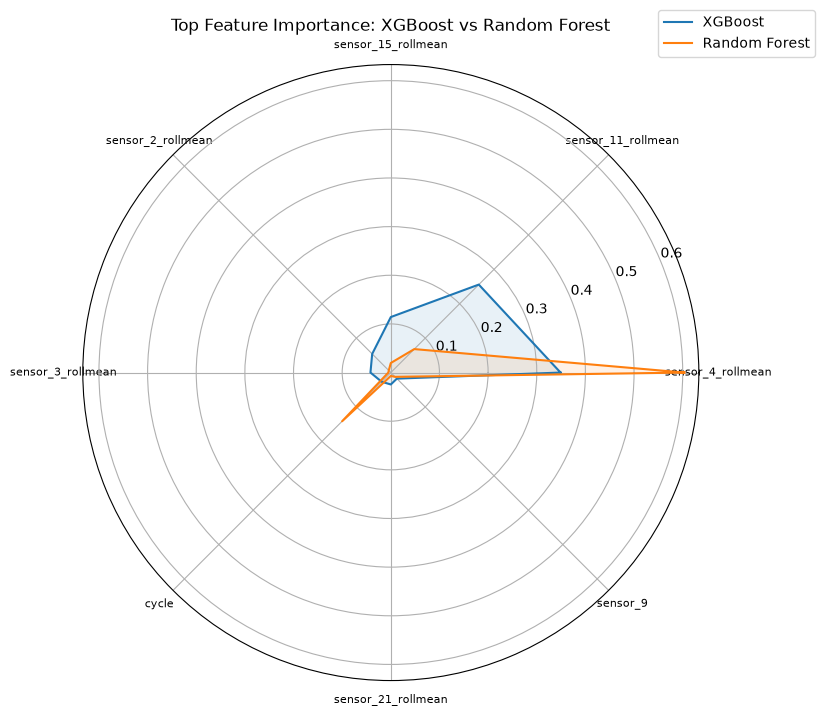

In [24]:
top_n = 8
xgb_importances = importances.head(top_n)
rf_importances = pd.Series(best_rf.feature_importances_, index=feature_cols)[xgb_importances.index]

angles = np.linspace(0, 2*np.pi, top_n, endpoint=False).tolist()
xgb_vals = xgb_importances.values.tolist() + [xgb_importances.values[0]]
rf_vals = rf_importances.values.tolist() + [rf_importances.values[0]]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
ax.plot(angles, xgb_vals, label='XGBoost')
ax.fill(angles, xgb_vals, alpha=0.1)
ax.plot(angles, rf_vals, label='Random Forest')
ax.fill(angles, rf_vals, alpha=0.1)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(xgb_importances.index, fontsize=8)
ax.legend(loc='upper right', bbox_to_anchor=(1.2, 1.1))
plt.title('Top Feature Importance: XGBoost vs Random Forest')
plt.show()

**Key Insight:** `sensor_4_rollmean`, `sensor_11_rollmean`, and `sensor_15_rollmean` dominate XGBoost's top feature importances, consistent with their high raw correlation with RUL seen earlier. Random Forest assigns much flatter, more distributed importance across the same top features, showing the two models weight the same informative sensors differently despite comparable RMSE.

## Auxiliary Classification: Early Failure Warning
 
As a complementary framing to RUL regression, a binary classifier predicts whether an engine will fail within the next 30 cycles (`fail_soon`). This reframes the problem as an early-warning alert rather than a continuous life estimate, which is often more directly actionable for maintenance scheduling.

In [25]:
threshold = 30
train_fd001['fail_soon'] = (train_fd001['RUL'] <= threshold).astype(int)
val_fd001['fail_soon'] = (val_fd001['RUL'] <= threshold).astype(int)

y_train_clf = train_fd001['fail_soon']
y_val_clf = val_fd001['fail_soon']

In [26]:
from sklearn.ensemble import RandomForestClassifier

clf = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42, class_weight='balanced')
clf.fit(X_train, y_train_clf)
clf_probs = clf.predict_proba(X_val)[:, 1]

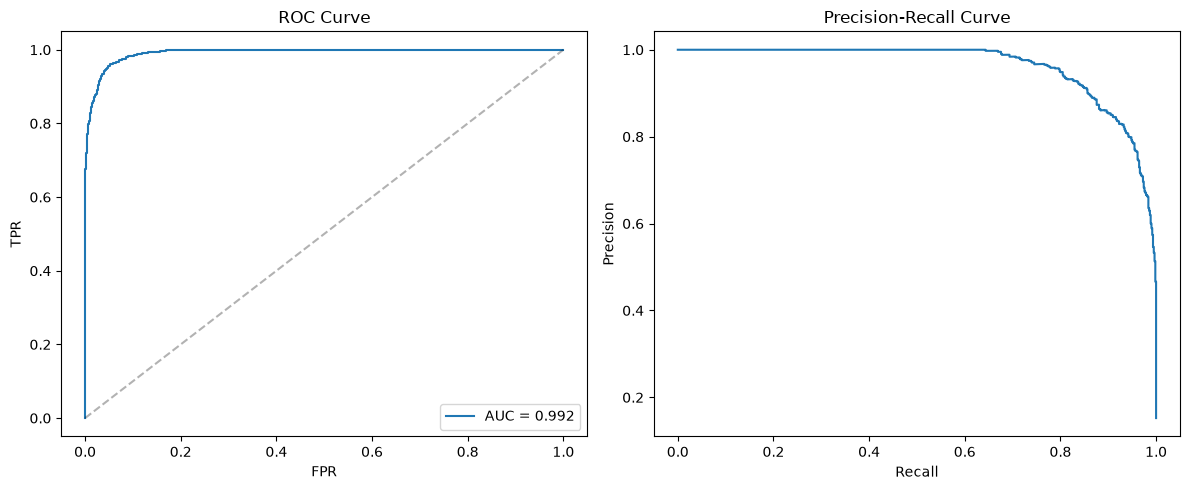

In [27]:
from sklearn.metrics import roc_curve, roc_auc_score, precision_recall_curve

fpr, tpr, _ = roc_curve(y_val_clf, clf_probs)
auc = roc_auc_score(y_val_clf, clf_probs)
precision, recall, _ = precision_recall_curve(y_val_clf, clf_probs)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(fpr, tpr, label=f'AUC = {auc:.3f}')
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.3)
axes[0].set_title('ROC Curve'); axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR'); axes[0].legend()

axes[1].plot(recall, precision)
axes[1].set_title('Precision-Recall Curve'); axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
plt.tight_layout()
plt.show()

**Key Insight:** The classifier achieves an AUC of 0.992 on the 30-cycle failure threshold, indicating strong separability between engines close to failure and healthy engines. This supports using RUL-derived alerts as a practical early-warning signal alongside the continuous RUL prediction.

## Business Impact — Simulated Maintenance Cost
 
To translate model accuracy into a business-relevant outcome, we simulate maintenance cost under two strategies: a fixed maintenance schedule versus model-driven maintenance triggered by predicted RUL, using illustrative cost assumptions for early maintenance, late failure, and fixed scheduling.

In [28]:
COST_EARLY_MAINTENANCE = 500
COST_LATE_FALIURE = 15000
COST_FIXED_SCHEDULE = 500

In [29]:
def simulated_cost(y_true, y_pred, threshold=30):
    total_cost = 0
    for true_rul, pred_rul in zip(y_true, y_pred):
        if pred_rul <= threshold:
            total_cost += COST_EARLY_MAINTENANCE
        else:
            if true_rul <= threshold:
                total_cost += COST_LATE_FALIURE 
    return total_cost

model_cost = simulated_cost(y_val.values, best_xgb.predict(X_val))
naive_cost = len(y_val) * COST_FIXED_SCHEDULE 

print(f'Model-driven maintenance cost: ${model_cost:,}')
print(f'Navie fixed_schedule cost : ${naive_cost:,}')
print(f'Simulated savings: ${naive_cost - model_cost:,} ({(1 - model_cost/naive_cost)*100:.1f}%)')              

Model-driven maintenance cost: $1,791,000
Navie fixed_schedule cost : $2,035,000
Simulated savings: $244,000 (12.0%)


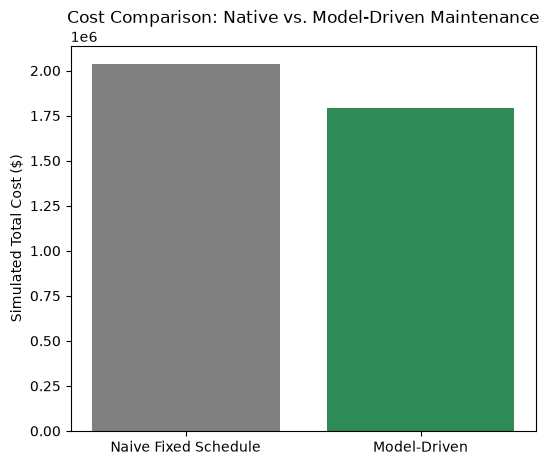

In [30]:
plt.figure(figsize=(6, 5))
plt.bar(['Naive Fixed Schedule', 'Model-Driven'], [naive_cost, model_cost], color=['gray', 'seagreen'])
plt.ylabel('Simulated Total Cost ($)')
plt.title('Cost Comparison: Native vs. Model-Driven Maintenance')
plt.show()

**Key Insight:** Model-driven maintenance produced a simulated cost of $1,791,000 versus $2,035,000 for a naive fixed schedule — a 12.0% simulated cost reduction. This translates the model's RMSE improvement into a concrete, business-relevant outcome rather than leaving it as an abstract error metric.

## Final Results
 
- **Best baseline model:** XGBoost — RMSE 14.75, CMAPSS Score 16,315.6 (FD001)
- **Feature engineering impact:** Rolling-mean features improved average sensor–RUL correlation by 10.7% over raw sensors; differencing features did not add standalone correlation signal
- **Most important features:** Rolling means of sensor_4, sensor_11, and sensor_15
- **Early-warning classification:** AUC 0.992 for predicting failure within 30 cycles
- **Simulated business impact:** ~12% maintenance cost reduction versus a fixed schedule

## Conclusion
 
This notebook transformed raw C-MAPSS sensor logs into a leakage-free, unit-split modeling dataset and established XGBoost as the baseline RUL prediction model (RMSE 14.75 on FD001), improving on Random Forest and Linear Regression. Rolling-mean features were shown to meaningfully strengthen sensor–RUL correlation, and a complementary early-warning classifier demonstrated strong (AUC 0.992) separability for near-failure engines. This baseline — model, processed data splits, and feature set — is the point of comparison for the deep learning sequence models developed in the following notebooks.